# 1. Project Overview & Configuration

In [ ]:
# data preprocessing
import pandas as pd
import numpy as np
import yaml
from collections import Counter

# machine learning (sklearn & xgboost)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb

#  XAI (SHAP & LIME)
import shap
import lime
import lime.lime_tabular

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# set seaborn theme
sns.set_theme(style="whitegrid")

d:\BKlecture\IntroToAI\repo_project\Project_IntroAI_20252_group21\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# 1. Load configuration from config.yaml
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

print("Configuration loaded successfully!")

# 2. Load data (UCI dataset uses ';' as delimiter)
data_path = f"../{config['data']['raw_path']}"
df = pd.read_csv(data_path, sep=';') 

print(f"Initial dataset shape: {df.shape}")

# [FIX BUG] Drop irrelevant macro/demographic columns to align with Web App logic
cols_to_drop = ['Age at enrollment', 'Inflation rate', 'GDP', 'Unemployment rate']
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Dataset shape after dropping irrelevant columns: {df.shape}")

# 3. Separate features (X) and target (y)
target_col = config['data']['target_col']
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Label Encoding for target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# [FIX BUG] Dynamically extract target names instead of hardcoding
target_names = le.classes_.tolist()
target_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Target classification mapping: {target_mapping}")

# 5. Train/Test split BEFORE SMOTE to prevent Data Leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=config['preprocessing']['test_size'], 
    random_state=config['preprocessing']['random_state'],
    stratify=y_encoded
)

# 6. Apply SMOTE to balance the training data
smote = SMOTE(random_state=config['preprocessing']['random_state'])
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 7. Standardize features (Z-score Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Data Layer complete! Data is ready for modeling.")

Configuration loaded successfully!
Initial dataset shape: (4424, 37)
Dataset shape after dropping irrelevant columns: (4424, 33)
Target classification mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Data Layer complete! Data is ready for modeling.


Starting Classification Model Training (Stage 1)...
Training Random Forest...
Training XGBoost...

 RANDOM FOREST MODEL RESULTS 
Accuracy: 0.7525
              precision    recall  f1-score   support

     Dropout       0.82      0.71      0.76       284
    Enrolled       0.46      0.52      0.48       159
    Graduate       0.83      0.87      0.85       442

    accuracy                           0.75       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.75      0.75       885


 XGBOOST MODEL RESULTS 
Accuracy: 0.7492
              precision    recall  f1-score   support

     Dropout       0.81      0.71      0.76       284
    Enrolled       0.46      0.53      0.49       159
    Graduate       0.83      0.85      0.84       442

    accuracy                           0.75       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.75      0.75       885



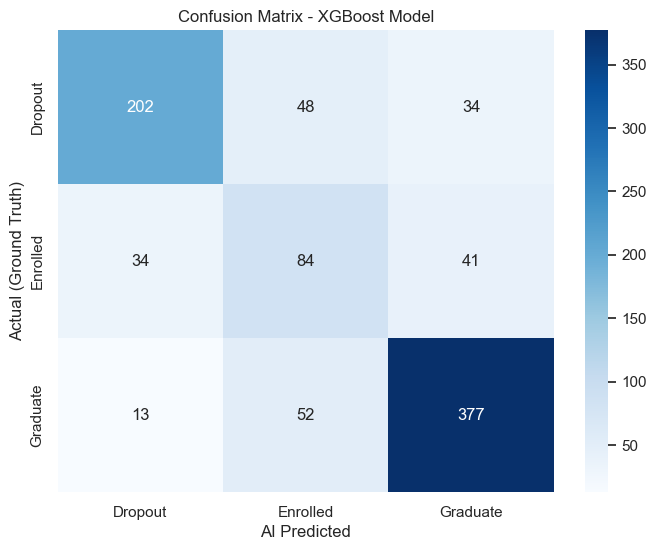

Prediction Layer (Stage 1) complete!


In [8]:
print("Starting Classification Model Training (Stage 1)...")

# 1. Initialize Random Forest and XGBoost models
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=config['preprocessing']['random_state']
)

xgb_model = xgb.XGBClassifier(
    n_estimators=config['model']['xgboost']['n_estimators'], 
    max_depth=config['model']['xgboost']['max_depth'], 
    learning_rate=config['model']['xgboost']['learning_rate'], 
    random_state=config['preprocessing']['random_state']
)

# 2. Train models on SMOTE-balanced and scaled training data
print("Training Random Forest...")
rf_model.fit(X_train_final, y_train_resampled)

print("Training XGBoost...")
xgb_model.fit(X_train_final, y_train_resampled)

# 3. Predict on unseen Test data 
y_pred_rf = rf_model.predict(X_test_final)
y_pred_xgb = xgb_model.predict(X_test_final)

# 4. Evaluate and compare models (Using dynamic target_names from Data Layer)
print("\n" + "="*40)
print(" RANDOM FOREST MODEL RESULTS ")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

print("\n" + "="*40)
print(" XGBOOST MODEL RESULTS ")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

# 5. Plot Confusion Matrix for XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Actual (Ground Truth)')
plt.xlabel('AI Predicted')
plt.title('Confusion Matrix - XGBoost Model')
plt.show()

print("Prediction Layer (Stage 1) complete!")

Starting XAI Layer (Stage 3): Model Explainability with SHAP & LIME...

Calculating SHAP values (This may take 1-2 minutes)...


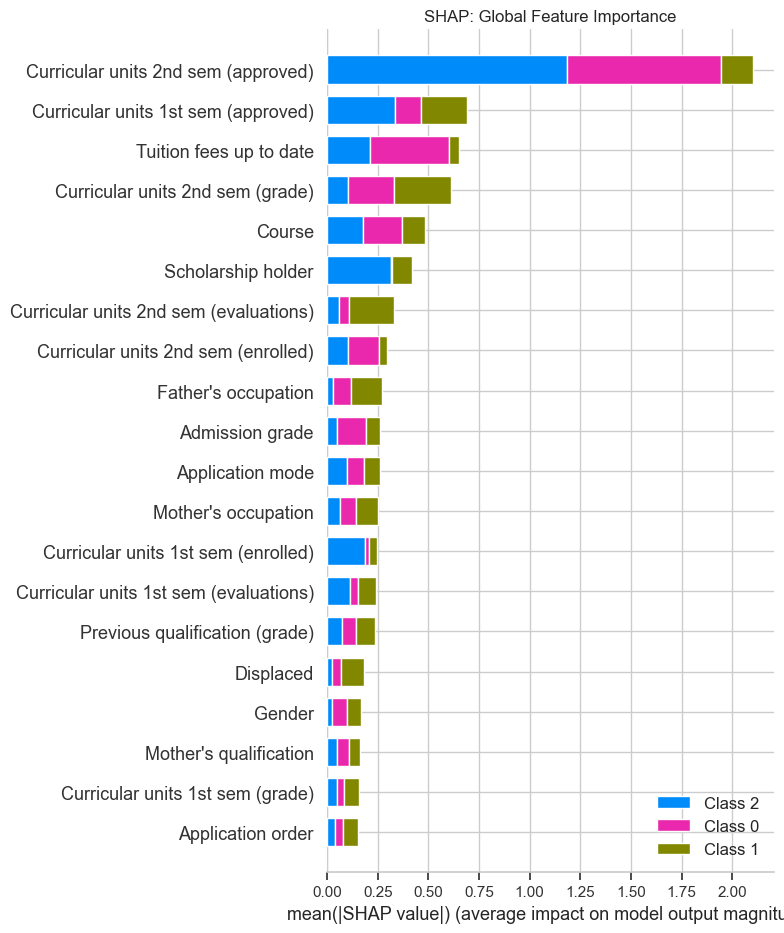


[LIME] Analyzing root causes for Dropout risk at index: 2
Ground Truth: Enrolled
AI Prediction: Dropout

LIME Explanation Results (Text format):
- Curricular units 2nd sem (approved) <= -0.68: -0.0655
- Father's occupation <= -0.27: -0.0374
- Course <= 0.10: 0.0284
- -1.13 < Mother's qualification <= -0.02: 0.0244
- Previous qualification (grade) <= -0.62: -0.0241

XAI Layer complete! Extracted insights are ready for LLM generation.


In [9]:
print("Starting XAI Layer (Stage 3): Model Explainability with SHAP & LIME...")

# ==========================================
# 1. SHAP - Global Feature Importance
# ==========================================
print("\nCalculating SHAP values (This may take 1-2 minutes)...")
explainer_shap = shap.TreeExplainer(xgb_model)
shap_values = explainer_shap.shap_values(X_test_final)

plt.figure(figsize=(10, 6))
# Handle multi-class SHAP values correctly (SHAP returns a list of arrays for multi-class)
shap.summary_plot(shap_values, X_test_final, plot_type="bar", show=False)
plt.title("SHAP: Global Feature Importance")
plt.tight_layout()
plt.show()

# ==========================================
# 2. LIME - Local Explanation for a Specific Student
# ==========================================
# [FIX BUG] Define wrapper function explicitly at the top level
def xgb_predict_proba_wrapper(data_array):
    """Bridge function: Converts LIME's numpy arrays back to DataFrames with strict column names for XGBoost."""
    df = pd.DataFrame(data_array, columns=X_train_final.columns)
    return xgb_model.predict_proba(df)

# Identify students predicted as 'Dropout' (Class index 0)
dropout_class_index = target_names.index("Dropout") if "Dropout" in target_names else 0
dropout_indices = [i for i, pred in enumerate(y_pred_xgb) if pred == dropout_class_index]

if len(dropout_indices) == 0:
    print("No students predicted as Dropout in the test set.")
else:
    sample_idx = dropout_indices[0] 
    print(f"\n[LIME] Analyzing root causes for Dropout risk at index: {sample_idx}")
    
    # Extract Ground Truth safely
    actual_label = target_names[y_test[sample_idx]]
    print(f"Ground Truth: {actual_label}")
    print(f"AI Prediction: {target_names[y_pred_xgb[sample_idx]]}")

    # Initialize LIME Explainer
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_final.values,
        feature_names=X_train_final.columns.tolist(),
        class_names=target_names,
        mode='classification',
        random_state=config['preprocessing']['random_state'] 
    )

    # Generate explanation
    exp = explainer_lime.explain_instance(
        data_row=X_test_final.iloc[sample_idx].values,
        predict_fn=xgb_predict_proba_wrapper, 
        num_features=5 
    )

    try:
        exp.show_in_notebook(show_table=True)
    except Exception:
        print("\nLIME Explanation Results (Text format):")
        for factor in exp.as_list():
            print(f"- {factor[0]}: {factor[1]:.4f}")

print("\nXAI Layer complete! Extracted insights are ready for LLM generation.")

In [ ]:
# 1. Trích xuất lý do rớt môn từ LIME (Chuyển list thành text)
# exp.as_list() sẽ trả về dạng: [('Tuition fees up to date <= 0', 0.25), ...]
lime_reasons = exp.as_list()

reasons_text = ""
for condition, weight in lime_reasons:
    # Lọc lấy các yếu tố có tác động tiêu cực (kéo sinh viên xuống nhóm Dropout)
    if weight > 0: 
        reasons_text += f"- Rào cản từ: {condition} (Mức độ ảnh hưởng: {weight:.2f})\n"

# 2. Xây dựng Prompt Framework chuẩn SageJavon (Meta Prompt + Augmented Info + Constraints)
system_prompt = """
Bạn là SmartEdu Advisor, một chuyên gia cố vấn học tập tận tâm tại trường Đại học. 
Nhiệm vụ của bạn là phân tích dữ liệu AI dự đoán để đưa ra lời khuyên cá nhân hóa, giúp sinh viên vượt qua nguy cơ bỏ học (Dropout).
Hãy giữ giọng điệu đồng cảm, khích lệ và thực tế.
"""

user_prompt = f"""
[THÔNG TIN SINH VIÊN]
- Trạng thái dự đoán của Hệ thống Cảnh báo sớm: NGUY CƠ BỎ HỌC (Dropout) CAO.
- Các nguyên nhân chính cản trở sinh viên (Trích xuất từ mô hình XAI):
{reasons_text}

[HƯỚNG DẪN ĐỌC DỮ LIỆU]
Lưu ý: Các giá trị số liệu ở trên đã được chuẩn hóa (Z-score). Giá trị âm (Ví dụ: -0.57) có nghĩa là chỉ số của sinh viên này thấp hơn/trẻ hơn mức trung bình của toàn trường. Biến "Course" đại diện cho mã ngành học mà sinh viên đang theo học.

[YÊU CẦU ĐẦU RA]
Dựa vào CÁC NGUYÊN NHÂN CỤ THỂ bên trên, hãy viết một bản báo cáo tư vấn ngắn gọn:
1. Chẩn đoán tình hình: Tóm tắt những rào cản thực tế mà sinh viên này đang gặp phải.
2. Lời khuyên hành động: Đưa ra 2-3 gợi ý thiết thực nhất để giúp sinh viên giải quyết ĐÚNG những rào cản vừa nêu (Ví dụ: Đổi ngành, tham gia CLB để làm quen môi trường, v.v.).
"""

# 3. Hiển thị thử Prompt xem đã chuẩn chưa trước khi gọi API của LLM
print("========== PROMPT ĐÃ ĐƯỢC TẠO TỰ ĐỘNG BỞI HỆ THỐNG ==========\n")
print(system_prompt)
print(user_prompt)
print("=============================================================")

========== PROMPT ĐÃ ĐƯỢC TẠO TỰ ĐỘNG BỞI HỆ THỐNG ==========


Bạn là SmartEdu Advisor, một chuyên gia cố vấn học tập tận tâm tại trường Đại học. 
Nhiệm vụ của bạn là phân tích dữ liệu AI dự đoán để đưa ra lời khuyên cá nhân hóa, giúp sinh viên vượt qua nguy cơ bỏ học (Dropout).
Hãy giữ giọng điệu đồng cảm, khích lệ và thực tế.


[THÔNG TIN SINH VIÊN]
- Trạng thái dự đoán của Hệ thống Cảnh báo sớm: NGUY CƠ BỎ HỌC (Dropout) CAO.
- Các nguyên nhân chính cản trở sinh viên (Trích xuất từ mô hình XAI):
- Rào cản từ: Age at enrollment <= -0.57 (Mức độ ảnh hưởng: 0.08)
- Rào cản từ: Course <= 0.10 (Mức độ ảnh hưởng: 0.05)


[HƯỚNG DẪN ĐỌC DỮ LIỆU]
Lưu ý: Các giá trị số liệu ở trên đã được chuẩn hóa (Z-score). Giá trị âm (Ví dụ: -0.57) có nghĩa là chỉ số của sinh viên này thấp hơn/trẻ hơn mức trung bình của toàn trường. Biến "Course" đại diện cho mã ngành học mà sinh viên đang theo học.

[YÊU CẦU ĐẦU RA]
Dựa vào CÁC NGUYÊN NHÂN CỤ THỂ bên trên, hãy viết một bản báo cáo tư vấn ngắn gọn:
1. Chẩ